In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_dir = "/content/drive/MyDrive/BrainTumor/dataset"

print(os.listdir(base_dir))

['augmented', 'test']


In [3]:
import os

classes = ["glioma", "meningioma", "pituitary"]

for folder in ["augmented", "test"]:
    print(f"\n{folder.upper()}")
    print("-" * 20)

    total = 0

    for class_name in classes:
        path = os.path.join(base_dir, folder, class_name)
        count = len(os.listdir(path))
        print(f"{class_name}: {count}")
        total += count

    print("Total:", total)


AUGMENTED
--------------------
glioma: 3421
meningioma: 3395
pituitary: 3719
Total: 10535

TEST
--------------------
glioma: 286
meningioma: 142
pituitary: 186
Total: 614


In [4]:
import os
import cv2
import numpy as np

classes = ["glioma", "meningioma", "pituitary"]

X_train = []
y_train = []

image_size = 240

for class_name in classes:

    folder_path = os.path.join(base_dir, "augmented", class_name)

    for filename in os.listdir(folder_path):

        image_path = os.path.join(folder_path, filename)

        # Check if the path is actually a file and not a directory like .ipynb_checkpoints
        if not os.path.isfile(image_path):
            continue

        img = cv2.imread(image_path)

        # Check if image was loaded successfully
        if img is None:
            print(f"Warning: Could not read image at {image_path}. Skipping.")
            continue

        img = cv2.resize(img, (image_size, image_size))

        X_train.append(img)
        y_train.append(class_name)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (10534, 240, 240, 3)
y_train shape: (10534,)


In [5]:
from collections import Counter

print("Images loaded per class:")
print(Counter(y_train))

Images loaded per class:
Counter({np.str_('pituitary'): 3719, np.str_('glioma'): 3420, np.str_('meningioma'): 3395})


In [ ]:
glioma_path = os.path.join(base_dir, "augmented", "glioma")

bad_files = []

for filename in os.listdir(glioma_path):

    image_path = os.path.join(glioma_path, filename)

    img = cv2.imread(image_path)

    if img is None:
        bad_files.append(filename)

print("Files that OpenCV cannot read:", bad_files)
print("Number of unreadable files:", len(bad_files))

Files that OpenCV cannot read: ['.ipynb_checkpoints']
Number of unreadable files: 1


In [6]:
X_test = []
y_test = []

for class_name in classes:

    folder_path = os.path.join(base_dir, "test", class_name)

    for filename in os.listdir(folder_path):

        image_path = os.path.join(folder_path, filename)

        img = cv2.imread(image_path)

        if img is None:
            continue

        img = cv2.resize(img, (image_size, image_size))

        X_test.append(img)
        y_test.append(class_name)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (614, 240, 240, 3)
y_test shape: (614,)


In [7]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=101)
X_test, y_test = shuffle(X_test, y_test, random_state=101)

print("Training:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (10534, 240, 240, 3) (10534,)
Test: (614, 240, 240, 3) (614,)


In [8]:
import tensorflow as tf

labels = ["glioma", "meningioma", "pituitary"]

# Convert class names to numbers
y_train_new = []

for i in y_train:
    y_train_new.append(labels.index(i))

y_train = y_train_new
y_train = tf.keras.utils.to_categorical(y_train)

# Do the same for test labels
y_test_new = []

for i in y_test:
    y_test_new.append(labels.index(i))

y_test = y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

In [9]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFirst 5 encoded train labels:")
print(y_train[:5])

X_train: (10534, 240, 240, 3)
y_train: (10534, 3)
X_test: (614, 240, 240, 3)
y_test: (614, 3)

First 5 encoded train labels:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [ ]:
from tensorflow.keras.applications import EfficientNetB2
import tensorflow as tf

image_size = 240

effnet = EfficientNetB2(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size, image_size, 3)
)

model = effnet.output

model = tf.keras.layers.GlobalAveragePooling2D()(model)

model = tf.keras.layers.Dropout(rate=0.5)(model)

model = tf.keras.layers.Dense(
    3,
    activation='softmax'
)(model)

model = tf.keras.models.Model(
    inputs=effnet.input,
    outputs=model
)

model.summary()

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 7,772,796 (29.65 MB)

 Trainable params: 7,705,221 (29.39 MB)

 Non-trainable params: 67,575 (263.97 KB)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/BrainTumor/models",
    exist_ok=True
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/BrainTumor/models/effnetb2_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.3,
    patience=5,
    min_delta=0.001,
    mode="auto",
    verbose=1
)

In [ ]:
from tensorflow.keras.callbacks import TensorBoard

tensorboard = TensorBoard(
    log_dir="logs"
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    verbose=1,
    batch_size=32,
    callbacks=[
        tensorboard,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8830 - loss: 0.2964
Epoch 1: val_accuracy improved from None to 0.96679, saving model to /content/drive/MyDrive/BrainTumor/models/effnetb2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor/models/effnetb2_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 283s 526ms/step - accuracy: 0.9326 - loss: 0.1827 - val_accuracy: 0.9668 - val_loss: 0.0955 - learning_rate: 0.0010
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9783 - loss: 0.0660
Epoch 2: val_accuracy did not improve from 0.96679
297/297 ━━━━━━━━━━━━━━━━━━━━ 61s 205ms/step - accuracy: 0.9761 - loss: 0.0700 - val_accuracy: 0.9156 - val_loss: 0.2733 - learning_rate: 0.0010
Epoch 3/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9831 - loss: 0.0436
Epoch 3: val_accuracy improved from 0.96679 to 0.98482, saving model to /content/drive/MyDrive/BrainTumor/models/effnetb2_best.keras

Epoch 3: finished saving model to /c

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/BrainTumor/models/effnetb2_best.keras"
)

print("Best B2 model loaded successfully.")

Best B2 model loaded successfully.


In [ ]:
loss, accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", round(accuracy * 100, 2))

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 500ms/step - accuracy: 0.9723 - loss: 0.1650
Test Loss: 0.16504111886024475
Test Accuracy: 0.9723126888275146
Test Accuracy (%): 97.23


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Predict on test data
y_pred = best_model.predict(X_test)

# Convert one-hot encoded labels to class indices
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred, axis=1)

# Class names
class_names = ['Glioma', 'Meningioma', 'Pituitary']

# Generate classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits = 4
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
              precision    recall  f1-score   support

      Glioma     0.9894    0.9790    0.9842       286
  Meningioma     0.9496    0.9296    0.9395       142
   Pituitary     0.9635    0.9946    0.9788       186

    accuracy                         0.9723       614
   macro avg     0.9675    0.9677    0.9675       614
weighted avg     0.9724    0.9723    0.9722       614



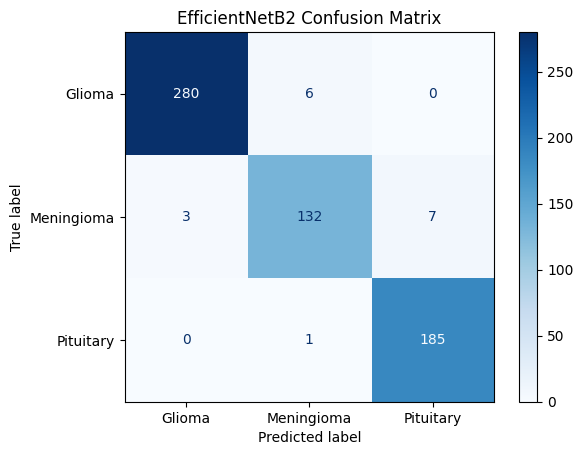

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', values_format='d')
plt.title("EfficientNetB2 Confusion Matrix")
plt.show()

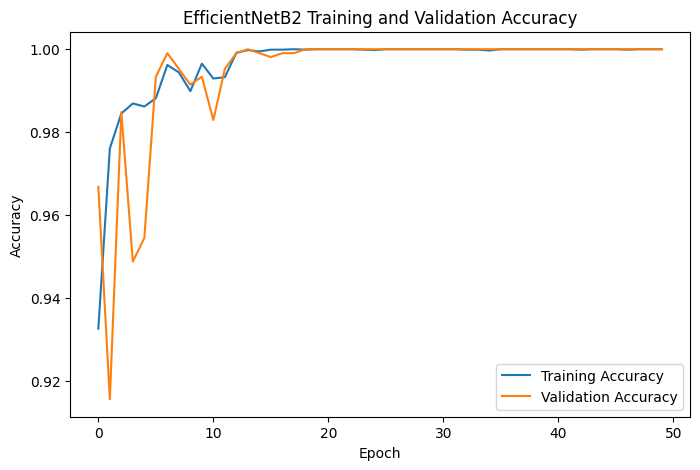

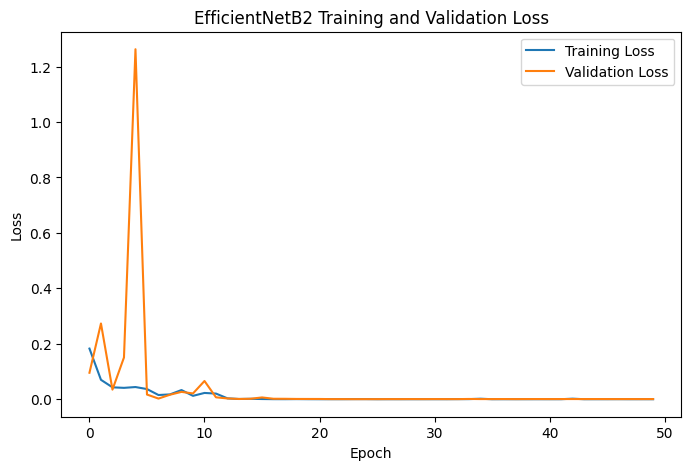

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('EfficientNetB2 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('EfficientNetB2 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# Load your best saved EfficientNetB2 checkpoint
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/BrainTumor/models/effnetb2_best.keras"
)

class_names = ["Glioma", "Meningioma", "Pituitary"]

# Authors' selected activation layer
last_conv_layer_name = "top_activation"

# Model returns both the feature maps and class predictions
grad_model = tf.keras.models.Model(
    inputs=best_model.inputs,
    outputs=[
        best_model.get_layer(last_conv_layer_name).output,
        best_model.output
    ]
)

def make_gradcam_heatmap(img_array, class_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    # Calculate gradients of the selected class score
    grads = tape.gradient(class_score, conv_outputs)

    # Average gradients across batch and spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature-map channels using the gradients
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep positive activations and normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy()


def plot_gradcam(image, true_label):
    # Add batch dimension; keep the same BGR input convention as your test arrays
    img_array = np.expand_dims(image, axis=0).astype("float32")

    predictions = best_model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])

    heatmap = make_gradcam_heatmap(img_array, predicted_index)

    # Resize heatmap to the MRI image dimensions
    heatmap_resized = cv2.resize(
        heatmap,
        (image.shape[1], image.shape[0])
    )

    # Convert heatmap to color and create overlay
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    colored_heatmap = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(
        image,
        0.6,
        colored_heatmap,
        0.4,
        0
    )

    # Convert BGR images to RGB only for display
    original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    heatmap_rgb = cv2.cvtColor(colored_heatmap, cv2.COLOR_BGR2RGB)

    confidence = predictions[0][predicted_index] * 100

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(overlay_rgb)
    axes[0].set_title("Grad-CAM Overlay")

    axes[1].imshow(original_rgb)
    axes[1].set_title(
        f"True: {class_names[true_label]}\n"
        f"Predicted: {class_names[predicted_index]} ({confidence:.2f}%)"
    )

    axes[2].imshow(heatmap_rgb)
    axes[2].set_title("Attention Map")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Actual class: Glioma


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 240, 240, 3))
  warnings.warn(msg)


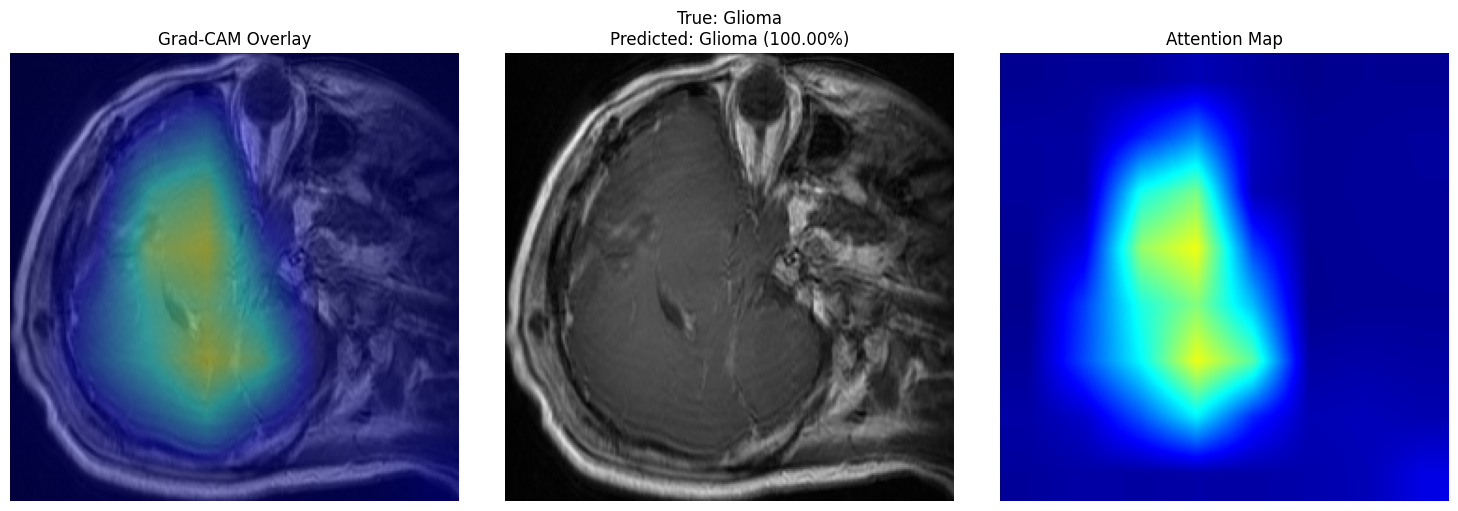

Actual class: Meningioma


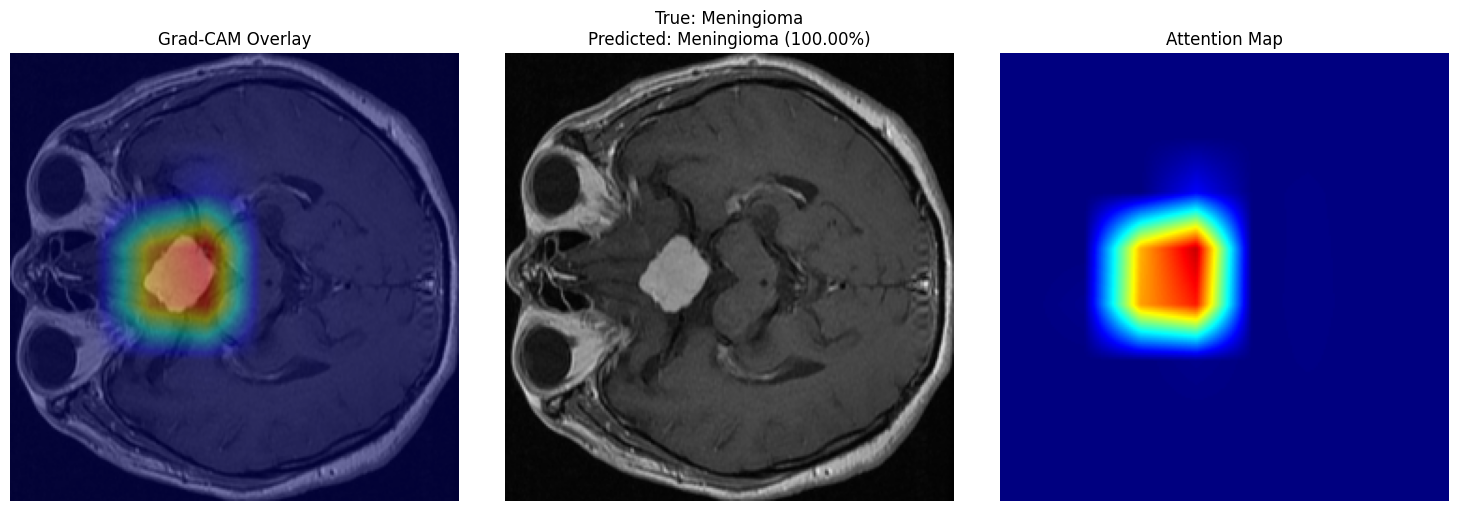

Actual class: Pituitary


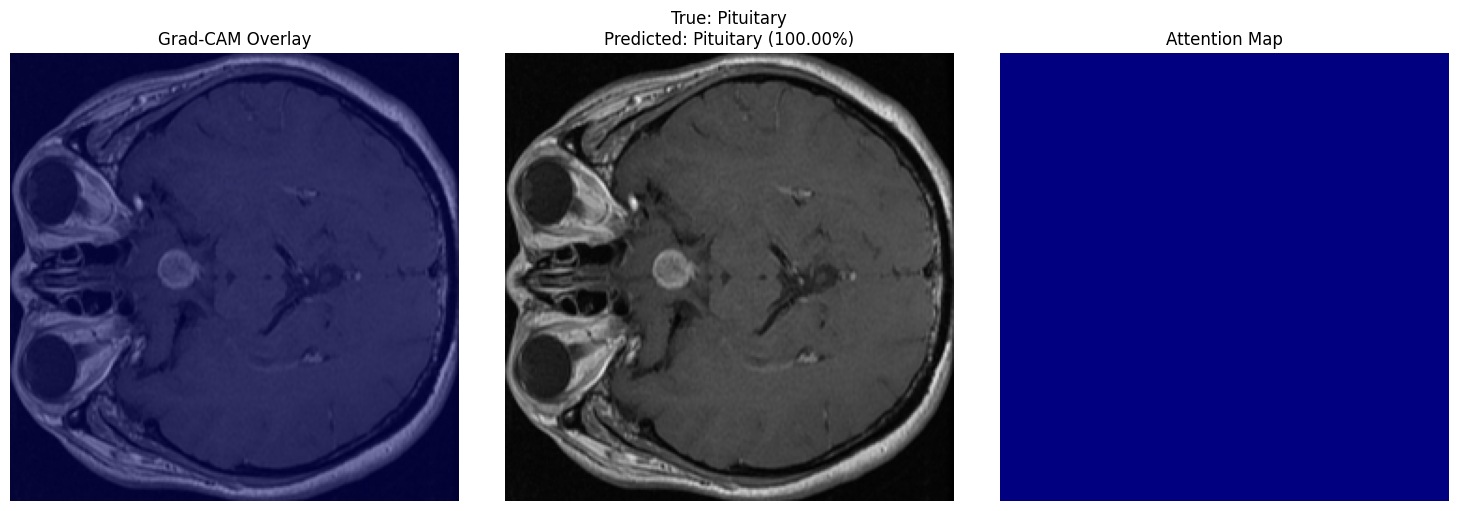

In [ ]:
# Select the first test image belonging to each actual class
for class_index, class_name in enumerate(class_names):
    indices = np.where(np.argmax(y_test, axis=1) == class_index)[0]

    if len(indices) == 0:
        print(f"No test image found for {class_name}")
        continue

    image_index = indices[0]

    print(f"Actual class: {class_name}")
    plot_gradcam(X_test[image_index], class_index)

B0 MODEL

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf

image_size = 240

effnetb0 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size, image_size, 3)
)

b0_model = effnetb0.output
b0_model = tf.keras.layers.GlobalAveragePooling2D()(b0_model)
b0_model = tf.keras.layers.Dropout(rate=0.5)(b0_model)
b0_model = tf.keras.layers.Dense(3, activation='softmax')(b0_model)

b0_model = tf.keras.models.Model(
    inputs=effnetb0.input,
    outputs=b0_model
)

b0_model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

b0_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 4,011,391 (15.30 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, TensorBoard

checkpoint = ModelCheckpoint(
    'models/EfficientNetB0.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.3,
    patience=5,
    min_delta=0.001,
    verbose=1
)

tensorboard = TensorBoard(log_dir='logs')

In [ ]:
history_b0 = b0_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[
        checkpoint,
        lr_scheduler,
        tensorboard
    ]
)

Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.8845 - loss: 0.2913
Epoch 1: val_accuracy improved from None to 0.92505, saving model to models/EfficientNetB0.keras

Epoch 1: finished saving model to models/EfficientNetB0.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 193s 344ms/step - accuracy: 0.9352 - loss: 0.1760 - val_accuracy: 0.9250 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9761 - loss: 0.0732
Epoch 2: val_accuracy improved from 0.92505 to 0.93738, saving model to models/EfficientNetB0.keras

Epoch 2: finished saving model to models/EfficientNetB0.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 42s 141ms/step - accuracy: 0.9786 - loss: 0.0667 - val_accuracy: 0.9374 - val_loss: 0.2114 - learning_rate: 0.0010
Epoch 3/50
296/297 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9726 - loss: 0.0842
Epoch 3: val_accuracy improved from 0.93738 to 0.95731, saving model to models/EfficientNetB0.keras

Epoch 3: finished savin

In [ ]:
from tensorflow.keras.models import load_model

best_b0_model = load_model('models/EfficientNetB0.keras')

test_loss_b0, test_accuracy_b0 = best_b0_model.evaluate(
    X_test,
    y_test
)

print("B0 Test Loss:", test_loss_b0)
print("B0 Test Accuracy:", test_accuracy_b0 * 100, "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 348ms/step - accuracy: 0.9788 - loss: 0.0967
B0 Test Loss: 0.09665370732545853
B0 Test Accuracy: 97.88273572921753 %


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Predict test images
y_pred_b0 = best_b0_model.predict(X_test)

# Convert one-hot labels and predictions to class indices
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_b0, axis=1)

# Class names
class_names = ['Glioma', 'Meningioma', 'Pituitary']

# Generate classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 357ms/step
              precision    recall  f1-score   support

      Glioma       1.00      0.99      0.99       286
  Meningioma       0.96      0.95      0.95       142
   Pituitary       0.97      0.99      0.98       186

    accuracy                           0.98       614
   macro avg       0.97      0.98      0.97       614
weighted avg       0.98      0.98      0.98       614



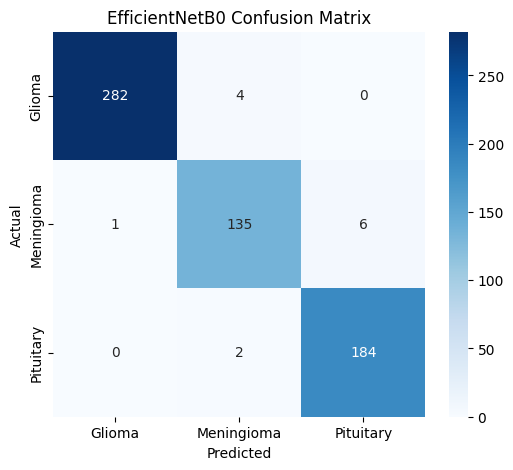

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm_b0 = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_b0,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EfficientNetB0 Confusion Matrix')
plt.show()

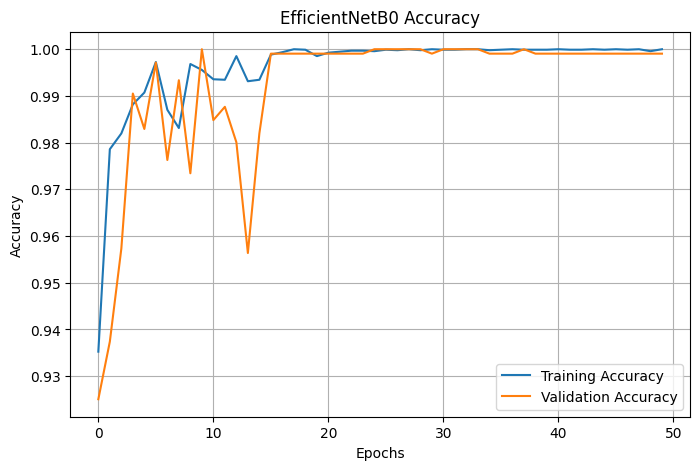

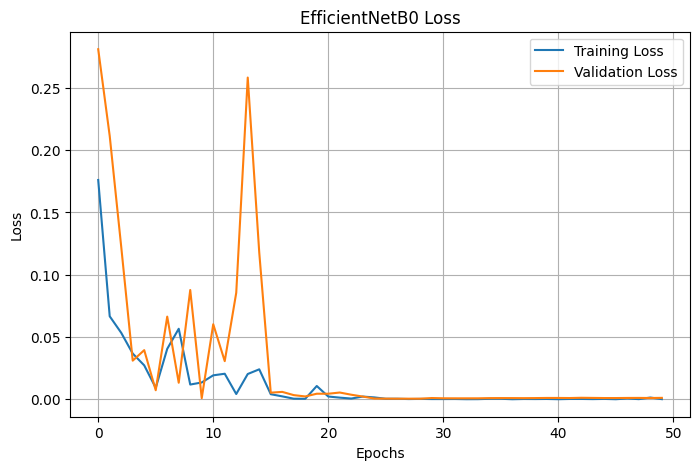

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history_b0.history['accuracy'], label='Training Accuracy')
plt.plot(history_b0.history['val_accuracy'], label='Validation Accuracy')
plt.title('EfficientNetB0 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history_b0.history['loss'], label='Training Loss')
plt.plot(history_b0.history['val_loss'], label='Validation Loss')
plt.title('EfficientNetB0 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# **B1 MODEL EVALUATION **

In [ ]:
from tensorflow.keras.applications import EfficientNetB1
import tensorflow as tf

effnetb1 = EfficientNetB1(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size, image_size, 3)
)

b1_model = effnetb1.output
b1_model = tf.keras.layers.GlobalAveragePooling2D()(b1_model)
b1_model = tf.keras.layers.Dropout(rate=0.5)(b1_model)
b1_model = tf.keras.layers.Dense(3, activation='softmax')(b1_model)

b1_model = tf.keras.models.Model(
    inputs=effnetb1.input,
    outputs=b1_model
)

b1_model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

b1_model.summary()

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 240, 240,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,579,082 (25.10 MB)

 Trainable params: 6,517,027 (24.86 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [ ]:
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, ReduceLROnPlateau
import os

os.makedirs("models", exist_ok=True)

tensorboard_b1 = TensorBoard(log_dir="logs/b1")

checkpoint_b1 = ModelCheckpoint(
    "models/EfficientNetB1.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="auto",
    verbose=1
)

lr_scheduler_b1 = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.3,
    patience=5,
    min_delta=0.001,
    mode="auto",
    verbose=1
)

In [ ]:
history_b1 = b1_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    verbose=1,
    batch_size=32,
    callbacks=[
        tensorboard_b1,
        checkpoint_b1,
        lr_scheduler_b1
    ]
)

Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8888 - loss: 0.2997
Epoch 1: val_accuracy improved from None to 0.96584, saving model to models/EfficientNetB1.keras

Epoch 1: finished saving model to models/EfficientNetB1.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 232s 453ms/step - accuracy: 0.9340 - loss: 0.1959 - val_accuracy: 0.9658 - val_loss: 0.0920 - learning_rate: 0.0010
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9758 - loss: 0.0663
Epoch 2: val_accuracy did not improve from 0.96584
297/297 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9773 - loss: 0.0659 - val_accuracy: 0.9469 - val_loss: 0.1436 - learning_rate: 0.0010
Epoch 3/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9799 - loss: 0.0582
Epoch 3: val_accuracy did not improve from 0.96584
297/297 ━━━━━━━━━━━━━━━━━━━━ 58s 196ms/step - accuracy: 0.9839 - loss: 0.0490 - val_accuracy: 0.9545 - val_loss: 0.1927 - learning_rate: 0.0010
Epoch 4/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
test_loss_b1, test_accuracy_b1 = b1_model.evaluate(X_test, y_test)

print("B1 Test Loss:", test_loss_b1)
print("B1 Test Accuracy:", test_accuracy_b1 * 100, "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 401ms/step - accuracy: 0.9853 - loss: 0.1022
B1 Test Loss: 0.10215765982866287
B1 Test Accuracy: 98.5342025756836 %


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Predict using B1
y_pred_probs = b1_model.predict(X_test)

# Convert predictions and actual labels to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Class names
class_names = ['Glioma', 'Meningioma', 'Pituitary']

# Display classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 560ms/step
              precision    recall  f1-score   support

      Glioma       1.00      0.99      0.99       286
  Meningioma       0.97      0.96      0.97       142
   Pituitary       0.97      0.99      0.98       186

    accuracy                           0.99       614
   macro avg       0.98      0.98      0.98       614
weighted avg       0.99      0.99      0.99       614



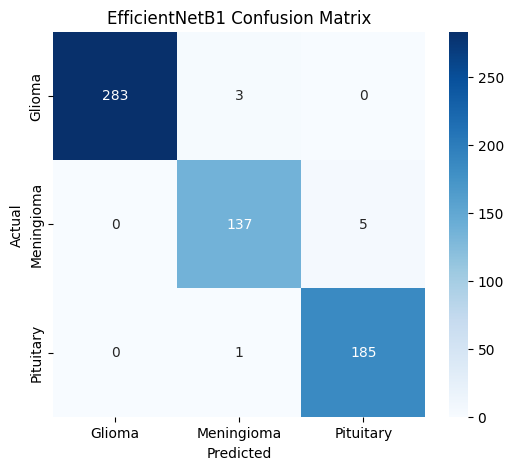

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EfficientNetB1 Confusion Matrix')
plt.show()

# B3 MODEL

In [10]:
from tensorflow.keras.applications import EfficientNetB3
import tensorflow as tf

effnetb3 = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size, image_size, 3)
)

b3_model = effnetb3.output
b3_model = tf.keras.layers.GlobalAveragePooling2D()(b3_model)
b3_model = tf.keras.layers.Dropout(rate=0.5)(b3_model)
b3_model = tf.keras.layers.Dense(3, activation='softmax')(b3_model)

b3_model = tf.keras.models.Model(
    inputs=effnetb3.input,
    outputs=b3_model
)

b3_model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

b3_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        960 │ block1a_se_excit

 Total params: 10,788,146 (41.15 MB)

 Trainable params: 10,700,843 (40.82 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [11]:
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, ReduceLROnPlateau
import os

os.makedirs("models", exist_ok=True)

tensorboard_b3 = TensorBoard(log_dir="logs/b3")

checkpoint_b3 = ModelCheckpoint(
    "models/EfficientNetB3.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="auto",
    verbose=1
)

lr_scheduler_b3 = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.3,
    patience=5,
    min_delta=0.001,
    mode="auto",
    verbose=1
)

In [12]:
history_b3 = b3_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    verbose=1,
    batch_size=32,
    callbacks=[
        tensorboard_b3,
        checkpoint_b3,
        lr_scheduler_b3
    ]
)

Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8759 - loss: 0.3252
Epoch 1: val_accuracy improved from None to 0.94497, saving model to models/EfficientNetB3.keras

Epoch 1: finished saving model to models/EfficientNetB3.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 335s 643ms/step - accuracy: 0.9278 - loss: 0.2080 - val_accuracy: 0.9450 - val_loss: 0.2487 - learning_rate: 0.0010
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9745 - loss: 0.0690
Epoch 2: val_accuracy improved from 0.94497 to 0.98482, saving model to models/EfficientNetB3.keras

Epoch 2: finished saving model to models/EfficientNetB3.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 106s 355ms/step - accuracy: 0.9758 - loss: 0.0720 - val_accuracy: 0.9848 - val_loss: 0.0551 - learning_rate: 0.0010
Epoch 3/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9864 - loss: 0.0405
Epoch 3: val_accuracy improved from 0.98482 to 0.98577, saving model to models/EfficientNetB3.keras

Epoch 3: finished savi

In [13]:
b3_model.load_weights("models/EfficientNetB3.keras")

test_loss_b3, test_acc_b3 = b3_model.evaluate(X_test, y_test)

print("B3 Test Loss:", test_loss_b3)
print("B3 Test Accuracy:", test_acc_b3 * 100, "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 558ms/step - accuracy: 0.9805 - loss: 0.0953
B3 Test Loss: 0.09528855979442596
B3 Test Accuracy: 98.04560542106628 %


In [14]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_b3 = np.argmax(b3_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report - B3")
print(classification_report(
    y_true,
    y_pred_b3,
    target_names=["Glioma", "Meningioma", "Pituitary"]
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 490ms/step
Classification Report - B3
              precision    recall  f1-score   support

      Glioma       0.99      0.99      0.99       286
  Meningioma       0.97      0.94      0.96       142
   Pituitary       0.97      0.99      0.98       186

    accuracy                           0.98       614
   macro avg       0.98      0.98      0.98       614
weighted avg       0.98      0.98      0.98       614



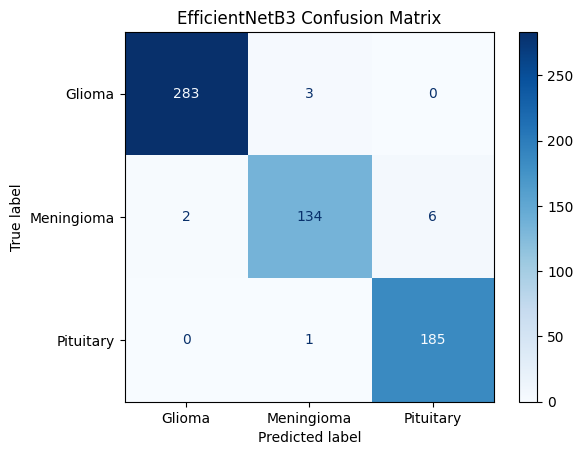

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_b3 = confusion_matrix(y_true, y_pred_b3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_b3,
    display_labels=["Glioma", "Meningioma", "Pituitary"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("EfficientNetB3 Confusion Matrix")
plt.show()

# **B4 MODEL**

In [17]:
from tensorflow.keras.applications import EfficientNetB4
import tensorflow as tf

effnetb4 = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size, image_size, 3)
)

b4_model = effnetb4.output
b4_model = tf.keras.layers.GlobalAveragePooling2D()(b4_model)
b4_model = tf.keras.layers.Dropout(rate=0.5)(b4_model)
b4_model = tf.keras.layers.Dense(3, activation='softmax')(b4_model)

b4_model = tf.keras.models.Model(
    inputs=effnetb4.input,
    outputs=b4_model
)

b4_model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

b4_model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 240, 240,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │      1,152 │ block1a_se_excit

 Total params: 17,679,202 (67.44 MB)

 Trainable params: 17,553,995 (66.96 MB)

 Non-trainable params: 125,207 (489.09 KB)

In [18]:
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, ReduceLROnPlateau
import os

os.makedirs("models", exist_ok=True)

tensorboard_b4 = TensorBoard(log_dir="logs/b4")

checkpoint_b4 = ModelCheckpoint(
    "models/EfficientNetB4.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="auto",
    verbose=1
)

lr_scheduler_b4 = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.3,
    patience=5,
    min_delta=0.001,
    mode="auto",
    verbose=1
)

In [19]:
history_b4 = b4_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    verbose=1,
    batch_size=32,
    callbacks=[
        tensorboard_b4,
        checkpoint_b4,
        lr_scheduler_b4
    ]
)

Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.8759 - loss: 0.3165
Epoch 1: val_accuracy improved from None to 0.97628, saving model to models/EfficientNetB4.keras

Epoch 1: finished saving model to models/EfficientNetB4.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 416s 869ms/step - accuracy: 0.9276 - loss: 0.2015 - val_accuracy: 0.9763 - val_loss: 0.1010 - learning_rate: 0.0010
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.9777 - loss: 0.0759
Epoch 2: val_accuracy did not improve from 0.97628
297/297 ━━━━━━━━━━━━━━━━━━━━ 149s 503ms/step - accuracy: 0.9781 - loss: 0.0717 - val_accuracy: 0.9639 - val_loss: 0.0940 - learning_rate: 0.0010
Epoch 3/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.9810 - loss: 0.0598
Epoch 3: val_accuracy did not improve from 0.97628
297/297 ━━━━━━━━━━━━━━━━━━━━ 148s 498ms/step - accuracy: 0.9842 - loss: 0.0487 - val_accuracy: 0.9639 - val_loss: 0.1387 - learning_rate: 0.0010
Epoch 4/50
297/297 ━━━━━━━━━━━━━━━━━━━━

In [20]:
b4_model.load_weights("models/EfficientNetB4.keras")

test_loss_b4, test_accuracy_b4 = b4_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("B4 Test Loss:", test_loss_b4)
print("B4 Test Accuracy:", test_accuracy_b4 * 100, "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 620ms/step - accuracy: 0.9837 - loss: 0.0794
B4 Test Loss: 0.07941968739032745
B4 Test Accuracy: 98.37133288383484 %


In [21]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_b4 = np.argmax(b4_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(
    y_true,
    y_pred_b4,
    target_names=["Glioma", "Meningioma", "Pituitary"]
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 595ms/step
              precision    recall  f1-score   support

      Glioma       0.99      0.99      0.99       286
  Meningioma       0.97      0.96      0.96       142
   Pituitary       0.98      0.99      0.98       186

    accuracy                           0.98       614
   macro avg       0.98      0.98      0.98       614
weighted avg       0.98      0.98      0.98       614



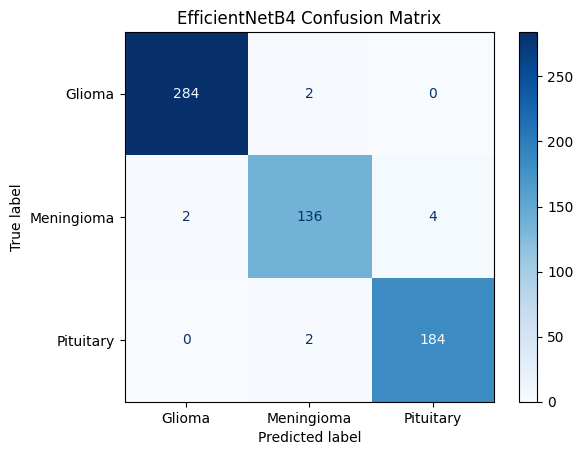

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_b4 = confusion_matrix(y_true, y_pred_b4)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_b4,
    display_labels=["Glioma", "Meningioma", "Pituitary"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("EfficientNetB4 Confusion Matrix")
plt.show()